# Devoir 5 420-A14-AS  (Apprentissage Automatique)

In this lab you'll train a decision tree classifier and a random forest classifier. You'll do so on both synthetic and real data.

**Run the code cell below** to import the required packages.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.tree        # For DecisionTreeClassifier class
import sklearn.ensemble    # For RandomForestClassifier class
import sklearn.datasets    # For make_circles
import sklearn.metrics     # For accuracy_score

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

# 1. Fitting a Random Forest classifier to synthetic data

Parts 1.1&ndash;1.4 ask you to apply scikit-learn's decision tree classifier (**[sklearn.tree.DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)**) and random forest classifier (**[sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)**) to synthetic data.

**Run the code cell below** to define some useful functions for plotting data and predictions.

In [2]:
def plot_data(X, y):
    """
    Plots a toy 2D data set. Assumes values in range [-3,3] and at most 3 classes.
    """
    plt.plot(X[y==0,0], X[y==0,1], 'ro', markersize=6)
    plt.plot(X[y==1,0], X[y==1,1], 'bs', markersize=6)
    plt.plot(X[y==2,0], X[y==2,1], 'gx', markersize=6, markeredgewidth=2)
    plt.xlim([-3, 3])
    plt.ylim([-3, 3])
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.gca().set_aspect('equal')
    
def plot_predict(model):
    """
    Plots the model's predictions over all points in range 2D [-3, 3].
    Assumes at most 3 classes.
    """
    extent = (-3, 3, -3, 3)
    x1min, x1max ,x2min, x2max = extent
    x1, x2 = np.meshgrid(np.linspace(x1min, x1max, 100), np.linspace(x2min, x2max, 100))
    X = np.column_stack([x1.ravel(), x2.ravel()])
    y = model.predict(X).reshape(x1.shape)
    cmap = matplotlib.colors.ListedColormap(['r', 'b', 'g'])
    plt.imshow(y, extent=extent, origin='lower', alpha=0.4, vmin=0, vmax=2, cmap=cmap)
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])
    plt.gca().set_aspect('equal')
    
def plot_class_probability(model, class_index):
    """
    Plots the model's class probability for the given class {0,1,2}
    over all points in range 2D [-3, 3]. Assumes at most 3 classes.
    """
    extent = (-3, 3, -3, 3)
    x1min, x1max ,x2min, x2max = extent
    x1, x2 = np.meshgrid(np.linspace(x1min, x1max, 100), np.linspace(x2min, x2max, 100))
    X = np.column_stack([x1.ravel(), x2.ravel()])
    p = model.predict_proba(X)[:,class_index].reshape(x1.shape)
    colors = [[1, 0, 0], [0, 0, 1], [0, 1, 0]]
    cmap = matplotlib.colors.ListedColormap(np.linspace([1, 1, 1], colors[class_index], 50))
    plt.imshow(p, extent=extent, origin='lower', alpha=0.4, vmin=0, vmax=1, cmap=cmap)
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])
    plt.gca().set_aspect('equal')    

<div style="border-bottom: 3px solid black;"></div>

### Part 1.1 &mdash; Train and inspect a small decision tree (2 points, 2 classes)

Read the documentation for the *DecisionTreeClassifier*'s **[fit](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.fit)** method. Notice that the $y$ vector should contain integer class labels.
You are asked to build the small 2D training set below:

$$
X = \begin{bmatrix}
-1 & 0\\
 1 & 0
\end{bmatrix},
\quad
y = \begin{bmatrix}
0\\
1
\end{bmatrix}
$$



**Write a few lines of code** to
1. Define the training set above in two variables $X$ and $y$.
2. Train a decision tree classifier on $X$ and $y$. Use argument *random_state*=0.
3. Plot the decision tree predictions and the data (use *plot_predict* and *plot_data* from preamble).
4. Plot the decision tree itself (use **[sklearn.tree.plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)**); pass `feature_names=['x1', 'x2']` as an argument.

You should end up with a plot showing the data and the decision surface between classes 0 (red) and class 1 (blue). You should see a binary decision tree diagram depicting a tree of height 1 that splits the feature space using the first variable (`x1`) at threshold 0.

*Tip 1:* If your code cell only outputs one figure, use `plt.figure()` to tell Matplotlib that you want the subsequent plotting commands to affect a new, separate figure.

*Tip 2:* If the last line of your code cell returns a value, it will be printed as the `Out` of the cell before the plots are shown. Some times you don't care about this 'final' value, for example if it is a string or some object you don't need printed. If you want to suppress the cell's `Out` value, add a semicolon (`;`) to the end of the last line of code in the cell.

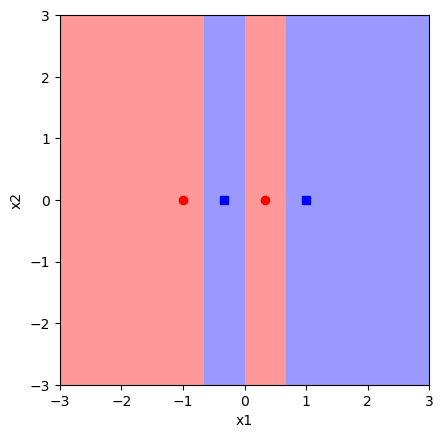

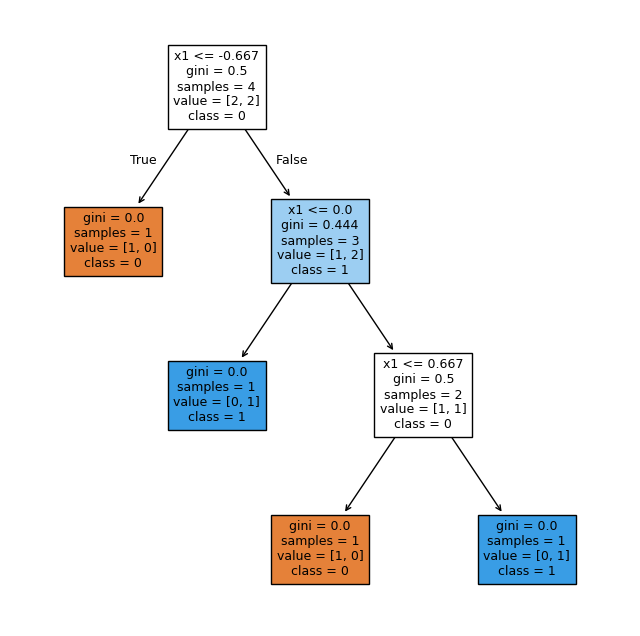

In [3]:
# Your code here. Aim for 7-9 lines.
X = np.array([[-1,0],
              [1,0],
              [-1/3,0],
              [1/3,0]])
y = np.array([0, 1,1, 0])
model  = sklearn.tree.DecisionTreeClassifier(random_state=0)
model.fit(X, y)
plot_data(X, y)

plot_predict(model)
plt.figure(figsize=(8,8))
sklearn.tree.plot_tree(model, feature_names=['x1', 'x2'], class_names=['0', '1'], filled=True, fontsize=9);


Once you have things working, **add two data points** to your training set: 
* $\mathbf{x}_3 = (-\frac{1}{3}, 0)$ with class label $y_3=1$ (blue), and
* $\mathbf{x}_4 = (\frac{1}{3}, 0)$ with class label $y_4=0$ (red).

**Re-run your code cell above** and make sure you understand how the splits and thresholds you see in the tree correspond to the decision region shown.

*Note:* If a decision tree node is shown as having *value*=[1,2], it means that node's region (before splitting) contains exactly one training point from class 0 and two training points from class 1. The root note thus 'contains' the entire training set.

<div style="border-bottom: 3px solid black;"></div>

### Part 1.2 &mdash; Train and inspect a small decision tree (3 points, 3 classes)

**Repeat Part 1.1** but with the following changes:
1. Add an extra training point $\mathbf{x}_3 = (0, -2)$ with class label $y_3=2$.
2. Print the **[feature_importances_](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_)** attribute of your trained decision tree. Intuitively, the feature importance is 0.0 if a feature is not used at all, or 1.0 if it is the only feature needed to make decisions.

This time you should see a binary decision tree of height 2, where the first split is done by thresholding the second feature (`X[1]`) and the second split is done by thresholding the first feature (`X[0]`). If a node has *value*=[1,1,0], it means that node's region (say, the red+blue region) contains exactly one training point from class 0, one training point from class 1, and zero training points from class 2.

3. Try incrementing *random_state* from 0 up to 9. How many distinct decision trees did you observe? Do the 'feature importances' make intuitive sense, given the trees that you observed?

Inportantce of features: [0.5 0.5]


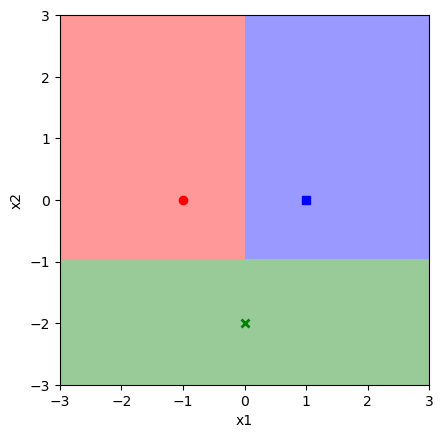

<Figure size 640x480 with 0 Axes>

In [4]:
# Your code here. Aim for 9-11 lines.
X = np.array([[-1,0],
              [1,0],
             [0,-2]])
y = np.array([0, 1,2])
model.fit(X, y)
plot_data(X, y)
plot_predict(model)
plt.figure()
print("Inportantce of features:", model.feature_importances_);
# for i in range(10):
#     model = sklearn.tree.DecisionTreeClassifier(random_state=i)
#     model.fit(X, y)
#     sklearn.tree.plot_tree(model, feature_names=['x1', 'x2'], class_names=['0', '1', '2'], filled=True, fontsize=9)
#     plt.figure()



<div style="border-bottom: 3px solid black;"></div>

### Part 1.3 &mdash; Train and inspect a small random forest (3 points, 3  classes)

The goal of this exercise is to show you how a random forest is a collection of decision trees.

**Repeat Part 1.2** but this time train using a random forest classifier (**[sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)**) on the same 3-point data set. Use *random_state*=0 and *n_estimators*=3. You should see a decision region that still has axis-aligned boundaries, but different from Part 1.2.

**What is random forest?**

Given a training set [1, 2, 3, 4], a random forest can be used to train a decision tree each time by different sub-collections/"re-samplings" of the training set, such as using [1, 1, 1, 2] to train the 1st decision tree or using [2, 3, 4, 4] to train the 2nd decision tree or using [1, 2, 3, 4] to train the 3rd decision tree.

Inportantce of features: [0.625 0.375]


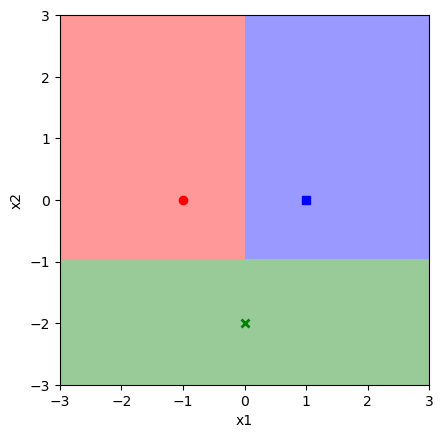

In [5]:
# Your code here. Aim for 9-11 lines. (OK to paste your data set building code from Part 1.2.)
X = np.array([[-1,0],
              [1,0],
             [0,-2]])
y = np.array([0, 1,2])
model = sklearn.ensemble.RandomForestClassifier(n_estimators=10, random_state=0)
model.fit(X, y)
plot_data(X, y)
plot_predict(model)
print("Inportantce of features:", model.feature_importances_)



A random forest builds multiple decision trees where each decision tree (each 'estimator') is trained on a different "re-samplings" of the training data. Specifically, decision tree $j$ is trained on a new training set $\mathcal{D}_j$ that is built by sampling $N$ pairs $(\mathbf{x}_i, y_i)$ from the original $N$ training examples in $\mathcal{D}$. The sampling is done "with replacement," meaning that the new training set $\mathcal{D}_j$ may be contain duplicates and/or be missing some of the original data.

With the *random_state* you have chosen, the three re-samplings of $\mathcal{D}=\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), (\mathbf{x}_3, y_3) \}$ are:
* $\mathcal{D}_1 = \{(\mathbf{x}_1, y_1), (\mathbf{x}_1, y_1), (\mathbf{x}_3, y_3) \}$ (red, red, green).
* $\mathcal{D}_2 = \{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), (\mathbf{x}_2, y_2) \}$ (red, red, blue).
* $\mathcal{D}_3 = \{(\mathbf{x}_2, y_2), (\mathbf{x}_2, y_2), (\mathbf{x}_3, y_3) \}$ (blue, blue, green).

Each individual decision tree is not a good classifier.
To make a prediction, the random forest collects a prediction from each tree, and returns the class with the most "votes." The winner of these votes tends to be a good classification.

**Plot the decision region and decision tree** for each of the three decision trees that comprise the random forest. Read about the *estimators_* attribute in the [*RandomForestClassifier* documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). Your answer should use a for-loop *over the estimators*, generating a plot for each one. Your code should generate three figures, where each figure contains two subplots (use Matplotlib's [subplot](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.subplot.html) function). Your first pair should look like this:

![image](img/random-forest-simple-estimator0.png)

*Hint:* Remember to use `plt.figure()` to start a new figure. Pass argument `figsize=(8,4)` to the *figure* function to make a figure that's twice as wide as it is tall.

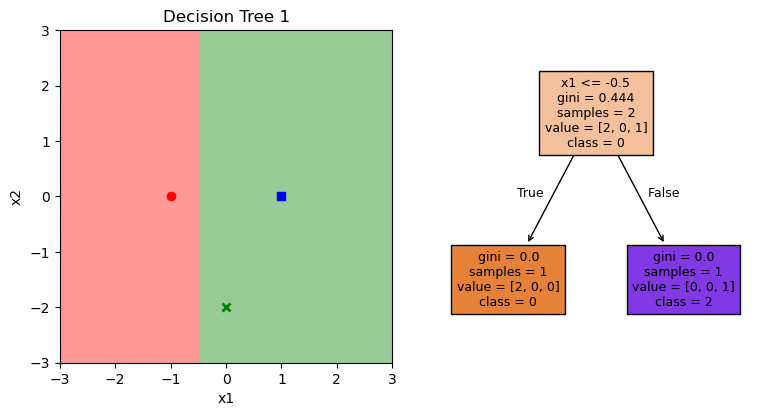

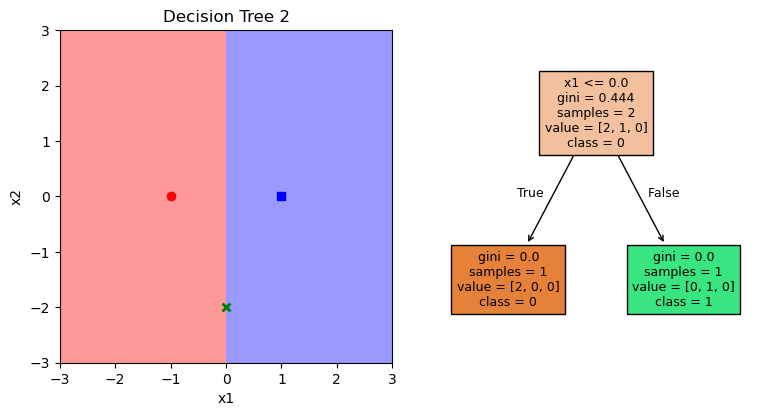

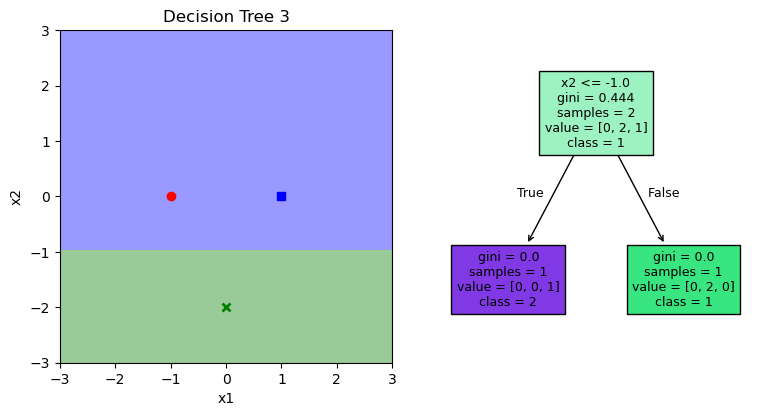

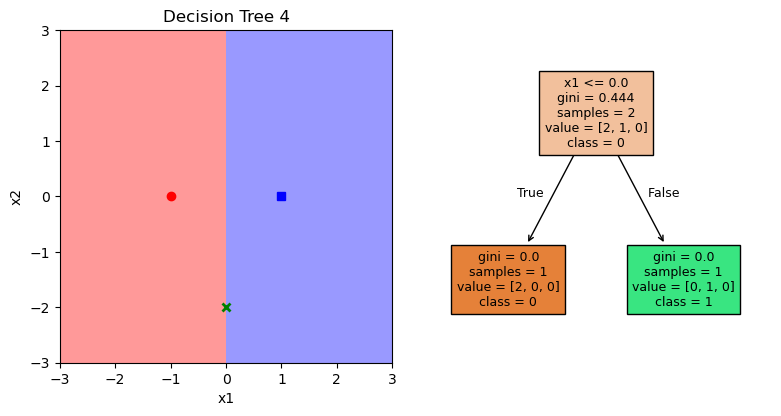

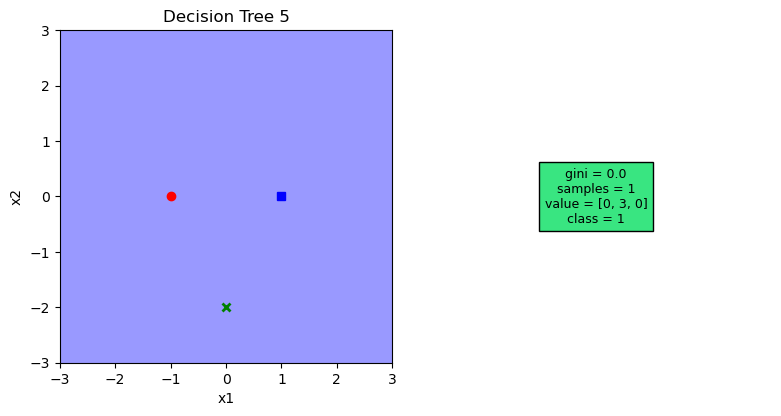

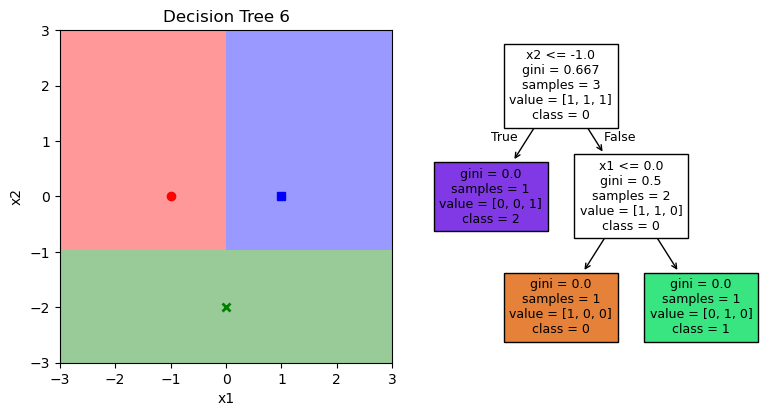

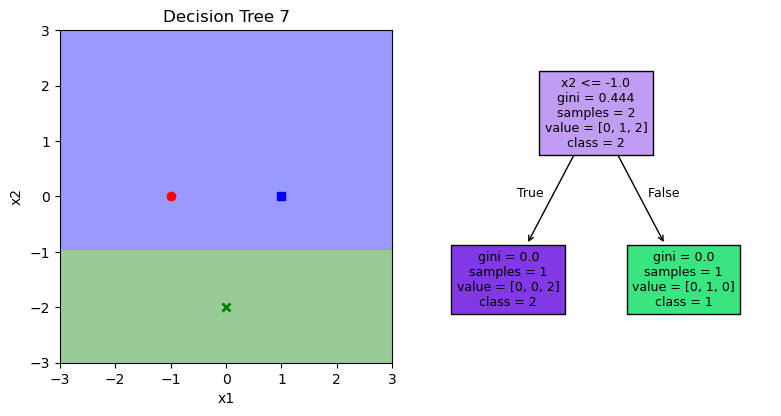

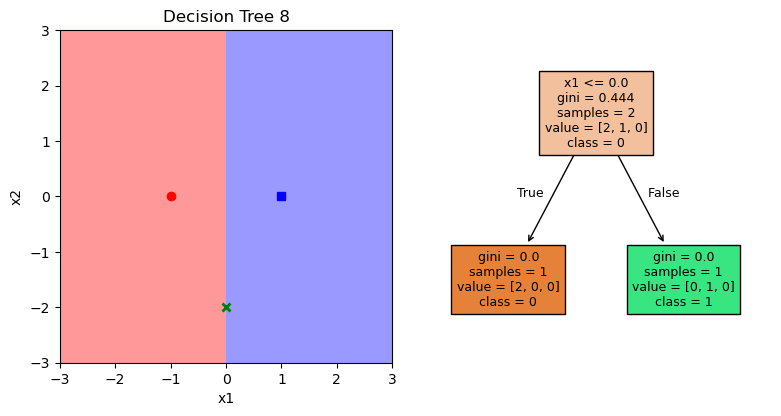

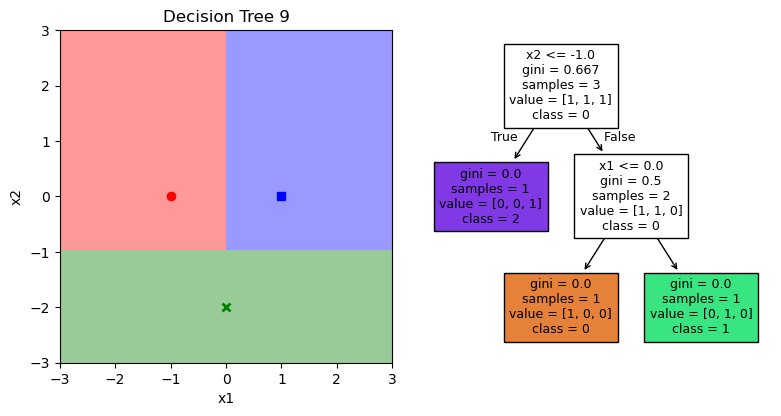

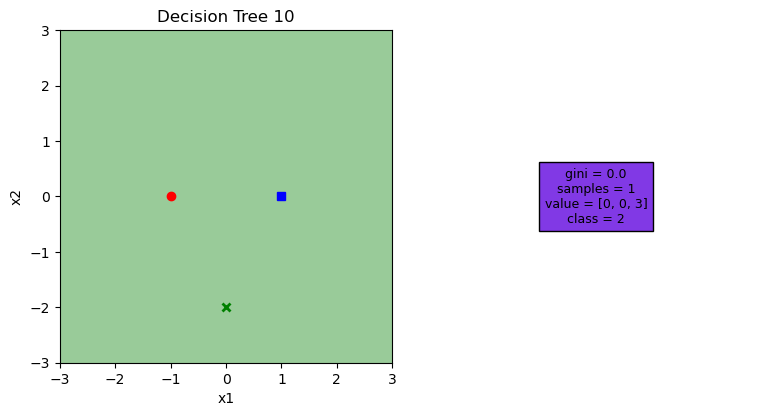

In [6]:
# Your plotting loop here. Aim for 8-10 lines.
estimators = model.estimators_
for i, estimator in enumerate(estimators):
    plt.figure(figsize=(8, 4))
    plt.subplot(1,2,1)
    plot_data(X, y)
    plot_predict(estimator)
    plt.title(f"Decision Tree {i+1}")

    plt.subplot(1,2,2)
    sklearn.tree.plot_tree(estimator, feature_names=['x1', 'x2'], class_names=['0', '1', '2'], filled=True,fontsize=9)
    plt.tight_layout()

To see how "votes" from the above decision trees are combined by a random forest, you should .

**Plot the class probabilities** reported by the *RandomForestClassifier* instance that you trained. Use Matplotlib's *figure*, *subplot*, and *colorbar* functions to create a single figure with three rows (one per class). For each subplot, use the *plot_class_probability* function (see preamble) to plot the heatmap of probablities. (This function calls *RandomForestClassifier*'s **[predict_proba](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.predict_proba)** method.) Your plot should look like this, but with the probabilities filled in:

![image](img/random-forest-simple-class-probabilities.png)

It's important not to confuse the number of trees with the number of classes, which in this case are both three.

*Tip:* As the figure you need to generate has three subplots in a row, I suggest setting *figsize=(13,3)*.

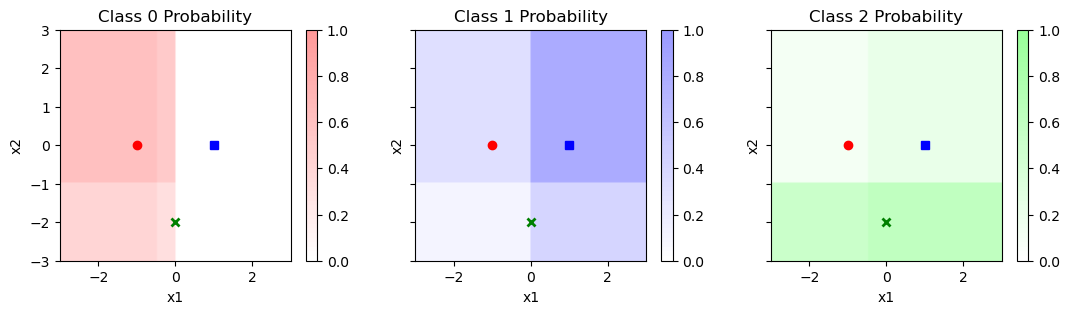

In [7]:
# Your code here. Aim for 7-8 lines.
fig, axes = plt.subplots(1,len([0, 1, 2]),figsize=(13, 3),sharey=True)
for i, class_index in enumerate([0, 1, 2]):
    plt.sca(axes[i])
    # plt.subplot(1,3,i+1)
    plot_data(X, y)
    plot_class_probability(model, class_index)
    plt.colorbar()
    plt.title(f"Class {class_index} Probability")


It is important to understand how the decision tree predictions lead to these probabilities. Inspect the shape of the decision regions proposed by each individual decision tree, and then ensure that you understand their correspondence with the class probabilities above.

Finally, once you understand how the three decision trees are combined, **re-run all code cells of Part 1.3** but use *n_estimators=10* so that there are now 10 decision trees. Notice how the final class probabilities change.

<div style="border-bottom: 3px solid black;"></div>

### Part 1.4 &mdash; Train and inspect a small random forest on a synthetic pattern

You are asked to train a random forest classifier on a synthetic binary classification data set. Use the **[sklearn.datasets.make_circles](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html)** function to create two concentric circles.

**Write a few lines of code** to:
1. Generate the circle data, with each circle made from 10 points. Use *random_state*=0.
2. For each *n_estimators* in $\{1, 2, 4, 8, 16, 32, 64\}$, train a random forest (use *random_state*=0) and plot its decision regions.

You first plot should look like this:
![image](img/random-forest-circle-decision-regions.png)

Take note of the correspondence between "more trees" and the quality of the combined decision regions.

note:
 As the number of trees increases, the combined decision regions become more stable, smoother, and generally more accurate because averaging many decision trees reduces variance and overfitting.


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

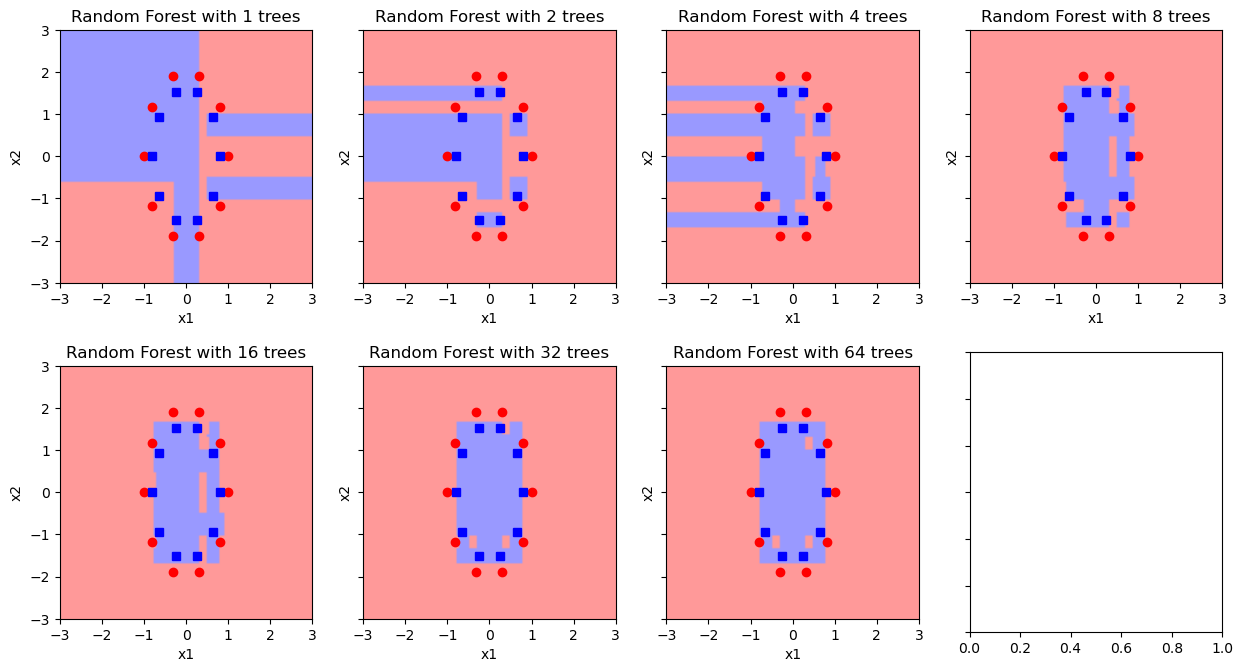

<Figure size 640x480 with 0 Axes>

In [8]:
# Your code here. Aim for 8-10 lines.
X,y = sklearn.datasets.make_circles(n_samples=20, random_state=0 )
X[:,1] *=2
n_estimators = [1,2,4,8,16,32,64]   
fig, axes = plt.subplots(2,4,figsize=(15, 8),sharey=True)
axes = axes.flatten()
for i, n in enumerate(n_estimators):
    plt.sca(axes[i])
    model = sklearn.ensemble.RandomForestClassifier(n_estimators=n, random_state=0)
    model.fit(X, y)
   
    plot_predict(model)
    plot_data(X, y)
    plt.title(f"Random Forest with {n} trees")
    plt.figure()
    
print("note:\n",
      "As the number of trees increases, the combined decision regions become more stable, smoother, and generally more accurate because averaging many decision trees reduces variance and overfitting.") 

**Plot the class probabilities** of the final random forest (the one with *n_estimators*=64) using the *plot_class_probability* function. You should generate one figure with two subplots, each with a colour bar, similar to Part 1.3. Your figure should look like this:

![image](img/random-forest-circle-class-probabilities.png)

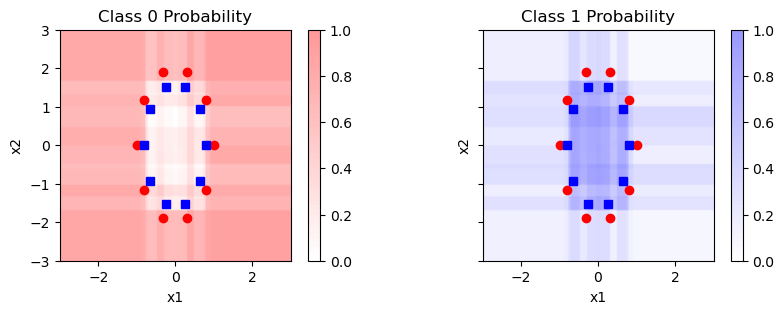

In [9]:
# Your code here. Aim for 7-9 lines.

fig, axes = plt.subplots(1,len([0, 1]),figsize=(10, 3),sharey=True)
for i, class_index in enumerate([0, 1]):
    plt.sca(axes[i])
    plot_data(X, y)
    plot_class_probability(model, class_index)
    plt.colorbar()
    plt.title(f"Class {class_index} Probability")

Notice how even though the decision region is compacy, the class probabilities have axis-aligned structure extending far away from the data.

Finally, **scale the second feature by a factor of two and re-run all code cells of Part 1.4**. You can scale the second feature by multiplying the second column in you $X$ matrix by $2$. You should see your circle vertically stretched.

After seeing all the results, make note of whether the decision regions simply scaled with the data or whether the decision regions qualitatively changed in any way.

Whether the decision regions qualitatively changed in any way?

Answer: Scaling the second feature by a factor of two only stretches the data and the corresponding decision regions. The qualitative shape of the decision regions remains essentially unchanged. Decision trees and random forests are largely invariant to feature scaling because they split based on feature order and thresholds rather than distances or magnitudes.

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

# 2. Fitting a Random Forest classifier to real data

Part 2.1&ndash;2.5 ask you to train and evaluate decision tree and random forest classifiers across multiple hyperparameters on real data.

<div style="border-bottom: 3px solid black;"></div>

### Part 2.1 &mdash; Load data from a CSV file and plot it

In this exercise you'll be loading the **[data_train.csv](data_train.csv)** and **[data_test.csv](data_test.csv)** files accompanying this lab. Here's a preview of the training data file:
```
sepal_length,sepal_width,label
4.9,2.4,1
4.8,3.0,0
5.1,3.3,0
7.7,3.0,2
6.2,2.8,2
...
```
This is part of the classic [Iris flower data set](https://en.wikipedia.org/wiki/Iris_flower_data_set).
The first two comman-separated columns are features. They encode characteristics of flowers. The last column is the class label, where each integer represents one of *Iris Setosa* (0), *Iris Versicolour* (1), and *Iris Virginica*.
 
**Write a few lines of code** to load each CSV file from disk. From the first file you should create variables *X_train* and *y_train* to refer to the training features (float64) and training labels (int32) respectively. From the second file you should likewise create variables *X_test* and *y_test*. Use the **[np.loadtxt](https://numpy.org/devdocs/reference/generated/numpy.loadtxt.html)** function to load the CSV like you did in Lab 4.

In [10]:
# Your code here. Aim for 6-8 lines.
train = np.loadtxt("./data_train.csv",skiprows=1,delimiter=',')
test = np.loadtxt("./data_test.csv",skiprows=1,delimiter=',')
X_train,y_train = train[:,:-1].astype(np.float64), train[:,-1].astype(np.int32)
X_test,y_test = test[:,:-1].astype(np.float64), test[:,-1].astype(np.int32)

**Check your answer** by running the code cell below.

In [11]:
assert 'X_train' in globals(), "No X_train variable!" 
assert 'y_train' in globals(), "No y_train variable!" 
assert 'X_test' in globals(), "No X_test variable!" 
assert 'y_test' in globals(), "No y_test variable!" 
assert isinstance(X_train, np.ndarray)
assert isinstance(y_train, np.ndarray)
assert isinstance(X_test, np.ndarray)
assert isinstance(y_test, np.ndarray)
assert X_train.shape == (80,2), "X_train was wrong shape!"
assert X_train.dtype in (np.float32, np.float64), "X_train was wrong data type!"
assert y_train.shape == (80,), "y_train was wrong shape!"
assert y_train.dtype == np.int32, "y_train was wrong data type!"
assert X_test.shape == (70,2), "X_test was wrong shape!"
assert X_test.dtype in (np.float32, np.float64), "X_test was wrong data type!"
assert y_test.shape == (70,), "y_test was wrong shape!"
assert y_test.dtype == np.int32, "y_test was wrong data type!"
print("Correct!")

Correct!


**Plot the training and testing data** by completing the plotting code below. When you run the code cell it will generate two figures, and the first one should look like this:

![image](img/iris-data-train.png)

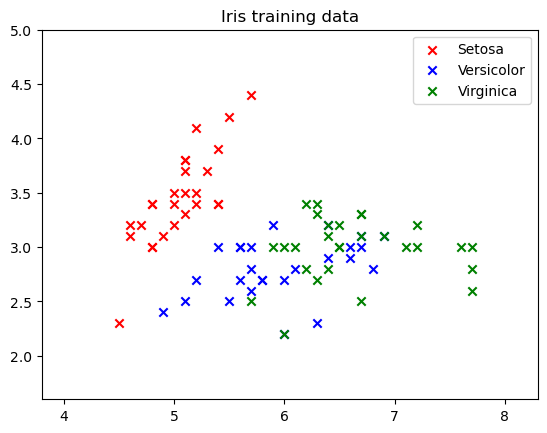

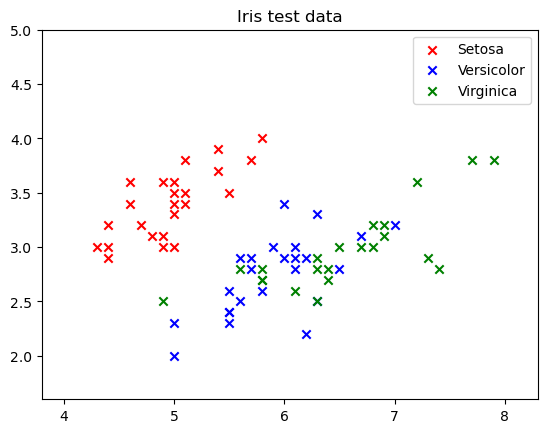

In [12]:
iris_extent = (3.8, 8.3, 1.6, 5)   # A good (x1min, x1max, x2min, x2max) for plotting iris data

def plot_iris_data(X, y, title):
    # Your plotting code here. Aim for 3 lines, plus a few for labels/title/legend/limits.
    plt.scatter(X[y==0,0], X[y==0,1],c='red', marker="x", label='Setosa')
    plt.scatter(X[y==1,0], X[y==1,1],c='blue', marker="x", label='Versicolor')
    plt.scatter(X[y==2,0], X[y==2,1],c='green', marker="x", label='Virginica')
    plt.xlim(iris_extent[0], iris_extent[1])
    plt.ylim(iris_extent[2], iris_extent[3])
    plt.legend(['Setosa', 'Versicolor', 'Virginica'])
                
    plt.title(title)
    
plt.figure()
plot_iris_data(X_train, y_train, 'Iris training data')

plt.figure()
plot_iris_data(X_test, y_test, 'Iris test data')

<div style="border-bottom: 3px solid black;"></div>

### Part 2.2 &mdash; Train a decision tree on the Iris data and plot it

You must train a decision tree on the Iris training data, and plot the decision regions. Your final result should look like this:

![image](img/iris-decision-tree-decision-region.png)

**Write a few lines of code** to:
1. Train a *DecisionTreeClassifier* object on the training data.
2. Plot the resulting predictor. Use *random_state*=0. 
3. Add text to your plot showing the accuracy of the classifier when predicting on the training data and when predicting on the held-out test data. Use the **[sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score)** function and Matplotlib's **[text](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.text.html)** function.

For plotting, you cannot use the *plot_predict* function from Part 1 because it assumes extents (-3, 3, -3, 3), but you can adapt that code to work for the range of Iris data below.

*Tip:* When you are formatting a string like `"%.1f" % accuracy` and you want to add a `%` symbol to the string, use two `%%` symbols in a row as in `"%.1f%%" % accuracy`. This lets Python know not to expect a second value to substitute into the string, and to just print `%` in that spot.

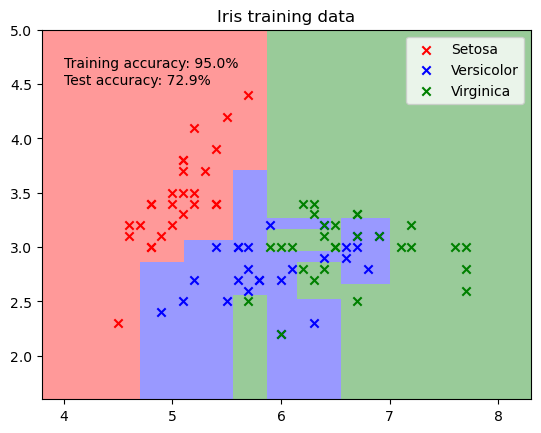

In [13]:
def plot_iris_predict(model):
    # Your prediction plotting code here. Aim for 8-12 lines.
   
    X1, X2 = np.meshgrid(np.linspace(iris_extent[0], iris_extent[1], 100), np.linspace(iris_extent[2], iris_extent[3], 100))
    X = np.column_stack([X1.ravel(), X2.ravel()])
    y = model.predict(X).reshape(X1.shape)
    plt.imshow(y,extent=iris_extent, origin='lower', alpha=0.4, vmin=0, vmax=2, cmap=matplotlib.colors.ListedColormap(['r', 'b', 'g']))
    # plt.contourf(X1, X2, y, alpha=0.4, vmin=0, vmax=2, cmap=matplotlib.colors.ListedColormap(['r', 'b', 'g']),levels=[-0.5,0.5,1.5,2.5])
    plot_iris_data(X_train, y_train, 'Iris training data')
    
    
    
# Your training, plotting, and evaluation code here. Aim for 7-9 lines.
model = sklearn.tree.DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)
plt.text(4,4.5, f"Training accuracy: {model.score(X_train, y_train)*100:.1f}%\nTest accuracy: {model.score(X_test, y_test)*100:.1f}%", fontsize=10)
# y_pred = model.predict(X_test)
# accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
plot_iris_predict(model)

**Plot the decision tree** using the *plot_tree* function. You'll need to use the *figure* function with *figsize*=(16,16) in order to make the figure large enough to see all the details. Remember the hint about ending a line with a semicolon (`;`). 

*Ask yourself: is this tree reasonably "interpretable" in your view?*

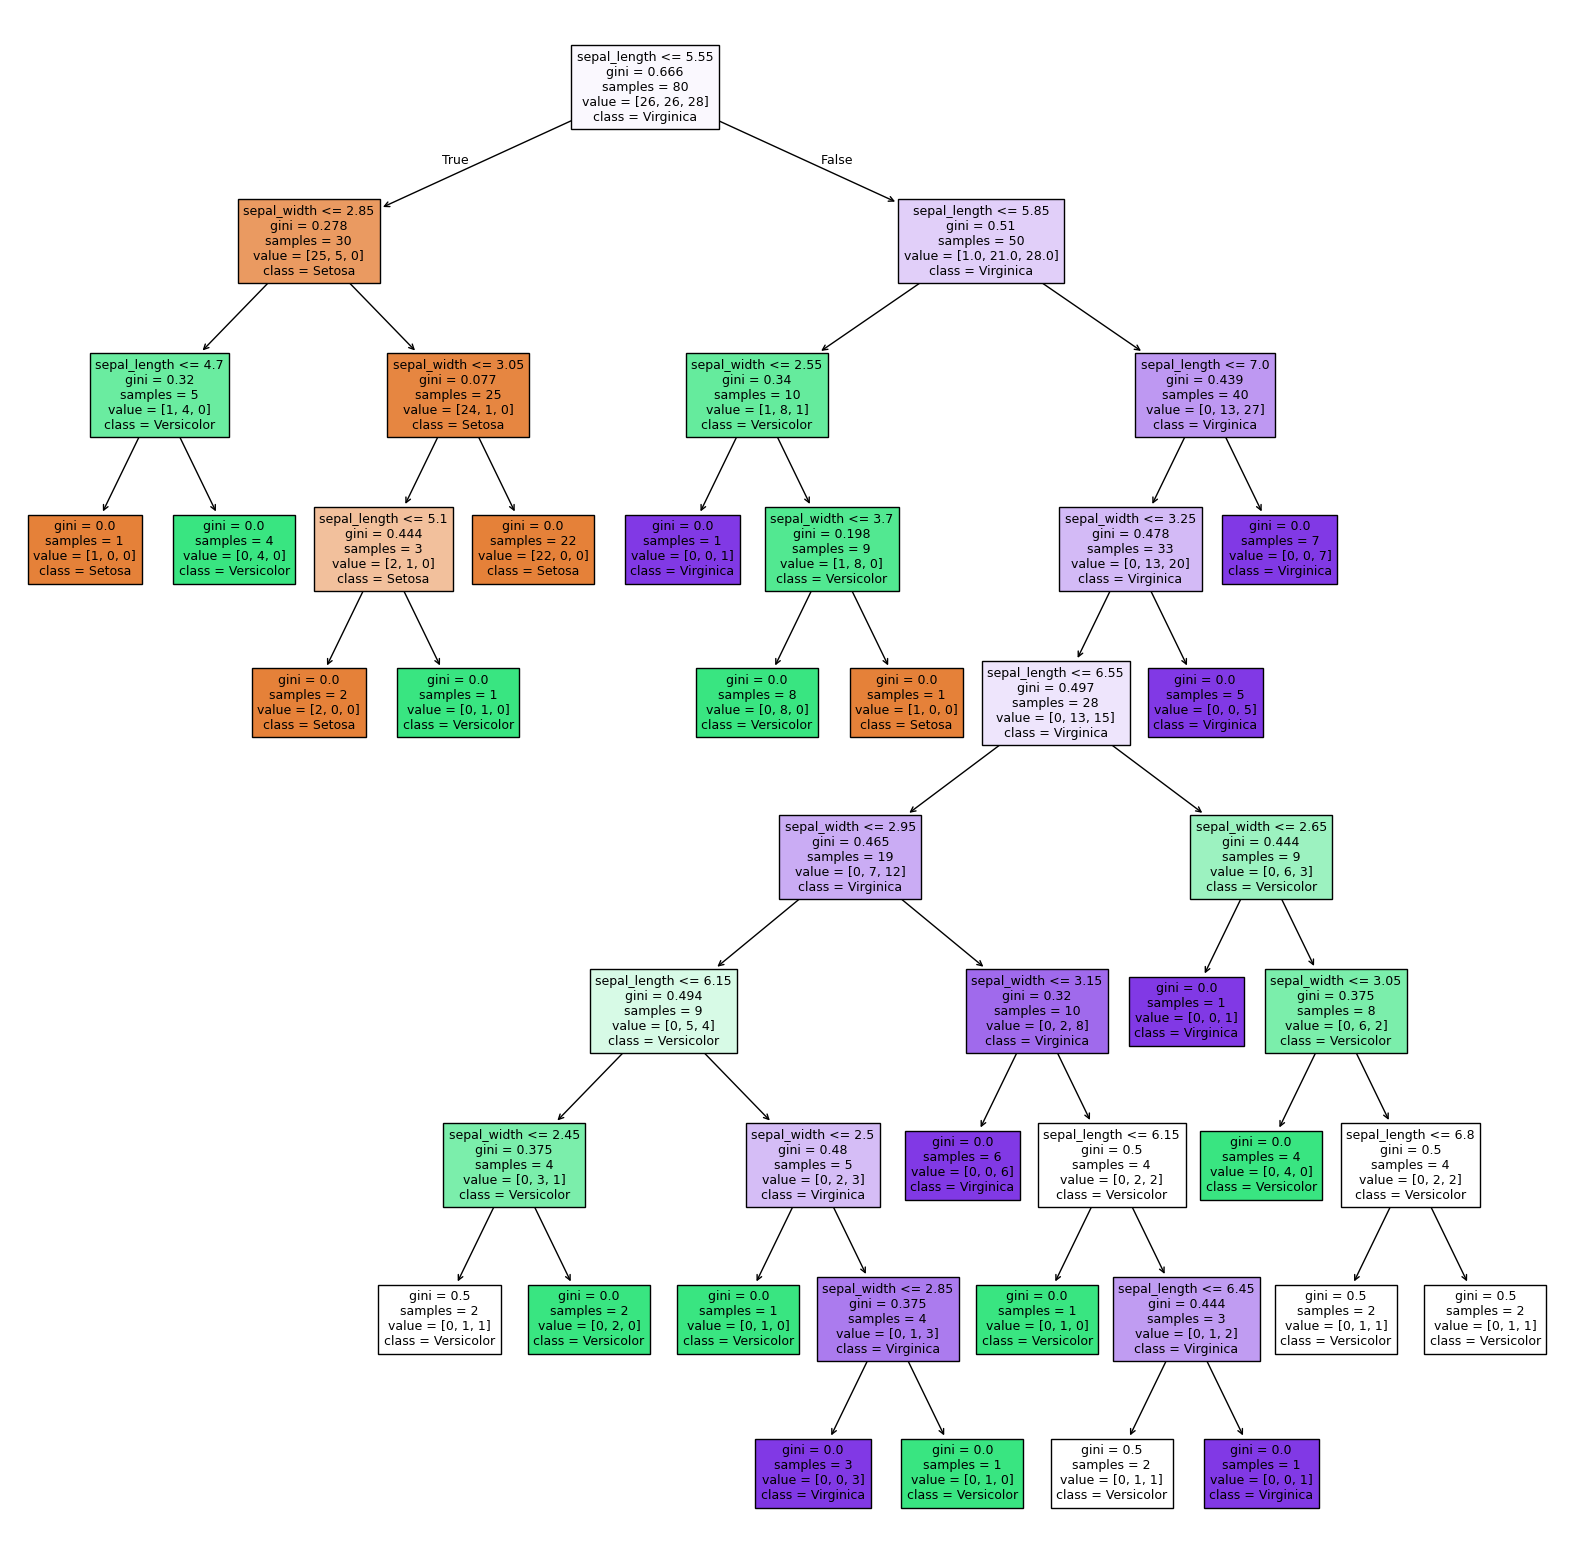

In [14]:
# Your code here. Aim for 2 lines.
fig =plt.figure(figsize=(20,20))
sklearn.tree.plot_tree(model,feature_names=["sepal_length", "sepal_width"],  class_names=['Setosa', 'Versicolor', 'Virginica'], filled=True, fontsize=9);

<div style="border-bottom: 3px solid black;"></div>

### Part 2.3 &mdash; Train decision trees of different depths

You are asked to train multiple decision trees, each with a different *max_depth* parameter, and plot the resulting decision regions and training/test accuracy. The maximum depth of a decision tree controls how finely the tree is allowed to split the feature space before it must predict a class label. A depth of 1 means it is only allowed one split. Your first figure should look like this:

![image](img/iris-decision-tree-max-depth-1.png)

**Write a few lines of code** to create nine figures: one for each value of *max_depth* $\in \{1, \ldots, 9\}$. Use a for-loop in your answer. On each iteration, train a new classifier using *random_state*=0. Use the *plot_iris_data* and your *plot_iris_predict* functions.

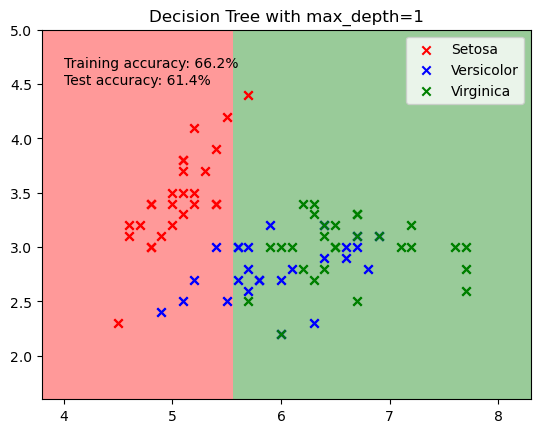

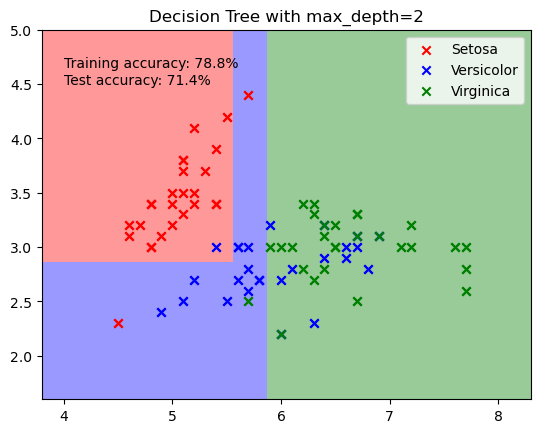

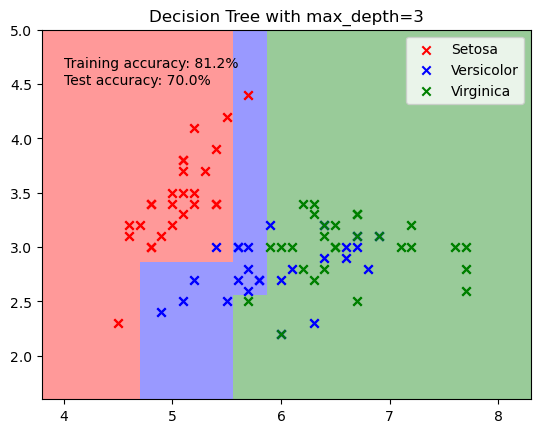

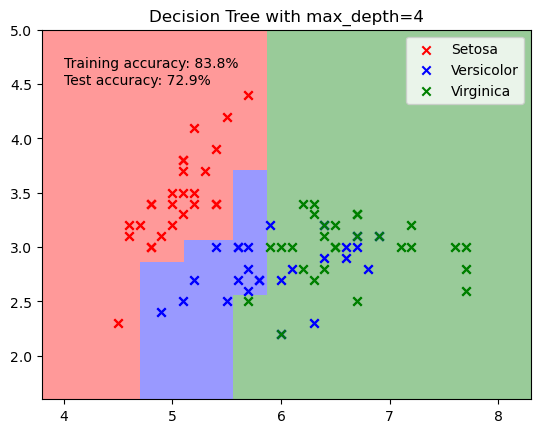

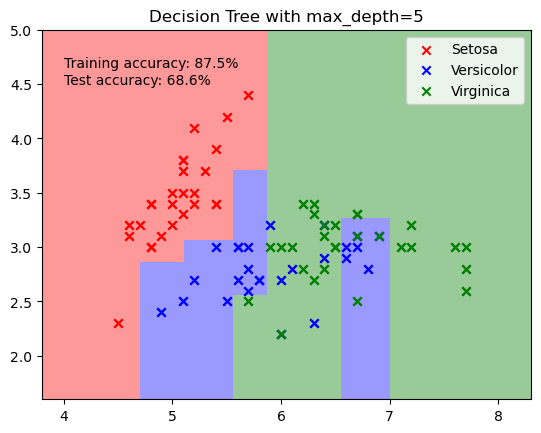

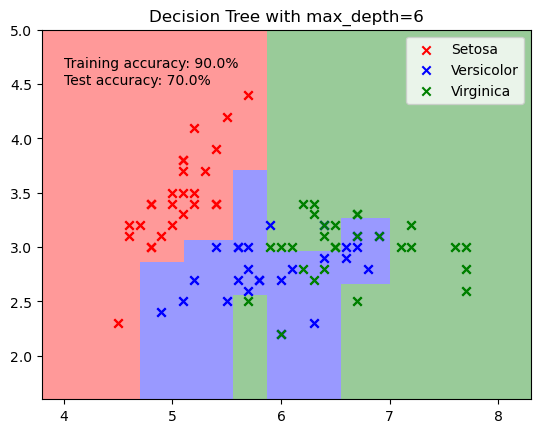

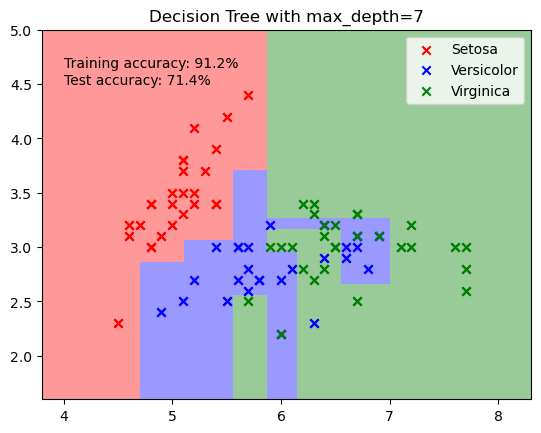

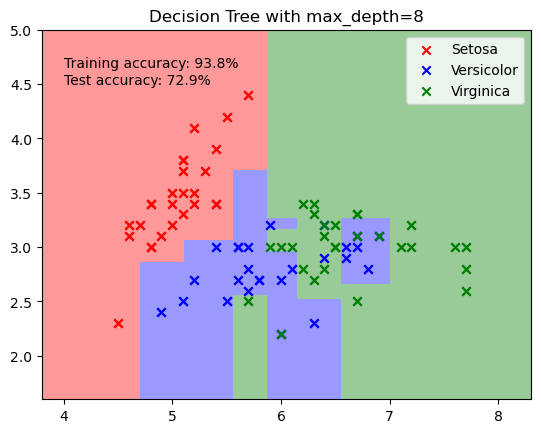

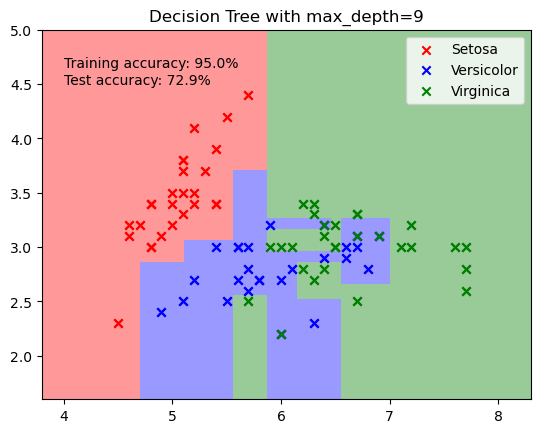

<Figure size 640x480 with 0 Axes>

In [15]:
# Your code here. Aim for 9-12 lines.
for i in range(9):
    model = sklearn.tree.DecisionTreeClassifier(random_state=0,max_depth=i+1)
    model.fit(X_train, y_train)
    plot_iris_predict(model)
    plot_iris_data(X_train, y_train, f'Decision Tree with max_depth={i+1}')
    plt.text(4,4.5, f"Training accuracy: {model.score(X_train, y_train)*100:.1f}%\nTest accuracy: {model.score(X_test, y_test)*100:.1f}%", fontsize=10)
    plt.figure();

What happens to the training accuracy as *max_depth* increases? What is the maximum test accuracy of a decision tree classifier on this data set?

Answer:

As the max_depth is increasing, the train accuracy basically is increasing as well. The maximum test accuracy of the decision tree on this data set is 72.9%.

<div style="border-bottom: 3px solid black;"></div>

### Part 2.4 &mdash; Train random forests of different depths

**Repeat Part 2.3** but this time train a *RandomForestClassifier* instead of a *DecisionTreeClassifier*. Use *random_state*=0 and *n_estimators*=100.

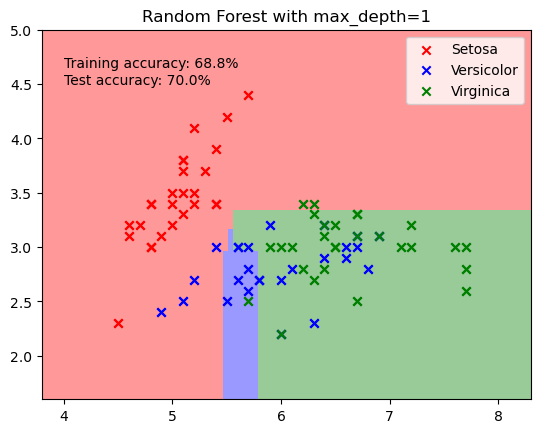

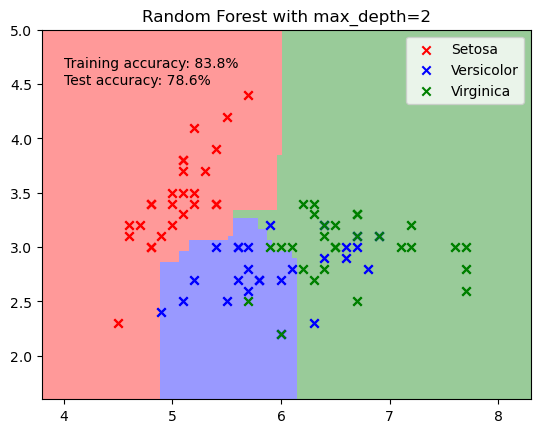

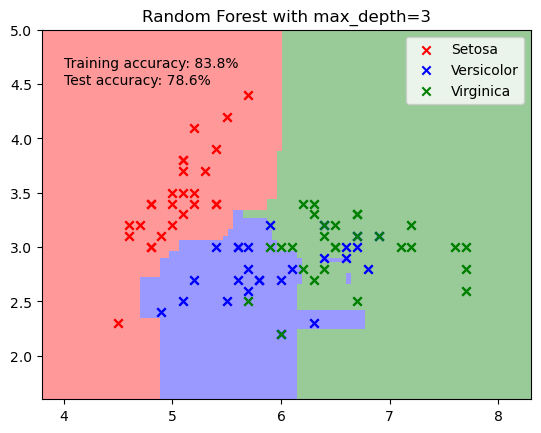

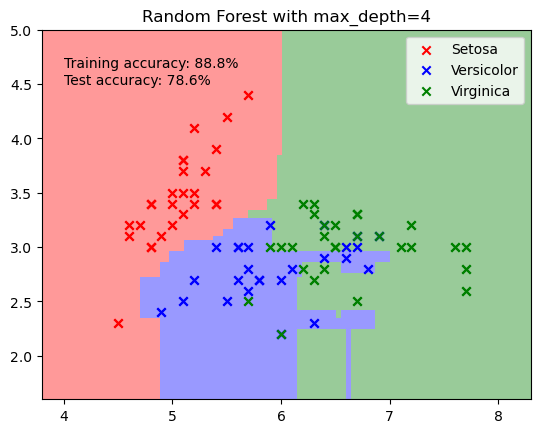

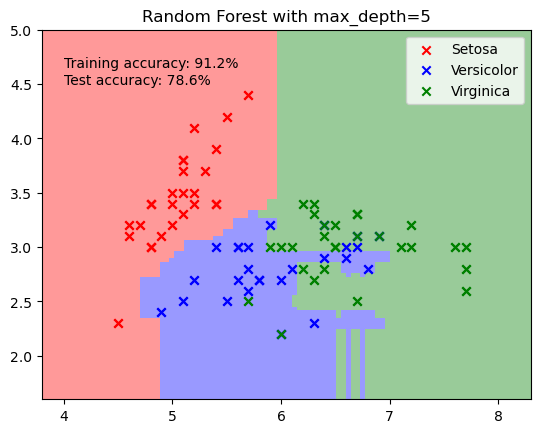

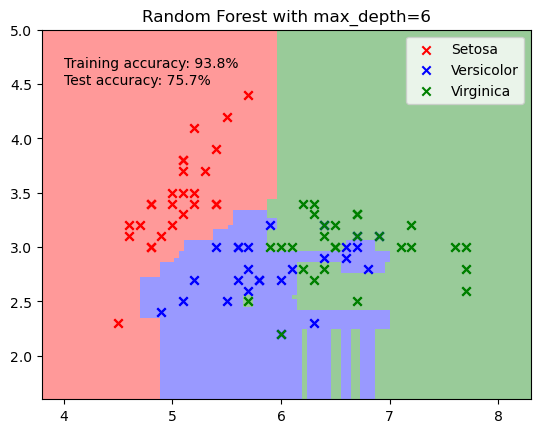

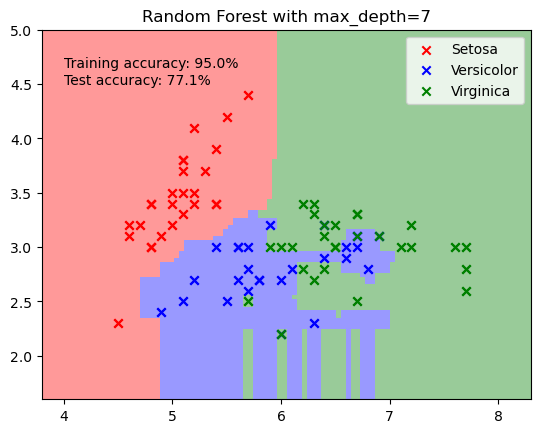

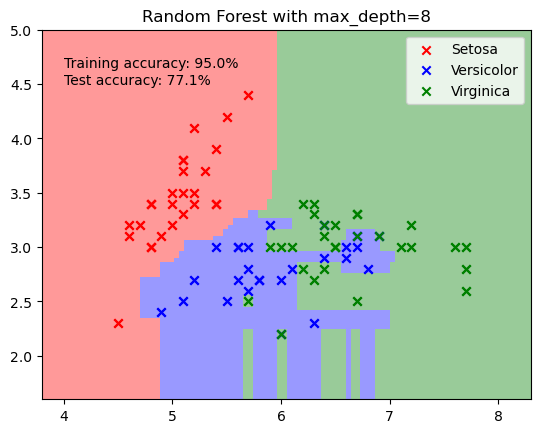

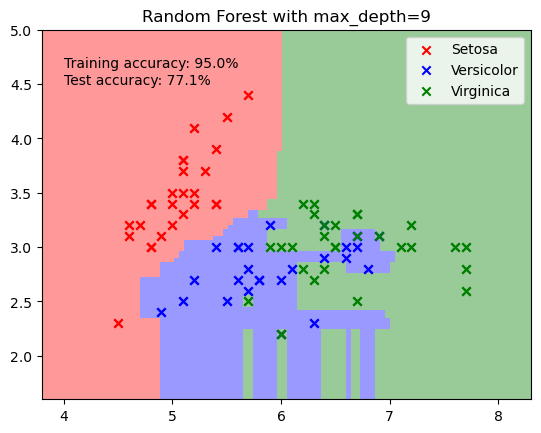

<Figure size 640x480 with 0 Axes>

In [16]:
# Your code here. Aim for 9-12 lines.

for i in range(9):
    model = sklearn.ensemble.RandomForestClassifier(random_state=0,n_estimators=100,max_depth=i+1)
    model.fit(X_train, y_train)
    plot_iris_predict(model)
    plot_iris_data(X_train, y_train, f'Random Forest with max_depth={i+1}')
    plt.text(4,4.5, f"Training accuracy: {model.score(X_train, y_train)*100:.1f}%\nTest accuracy: {model.score(X_test, y_test)*100:.1f}%", fontsize=10)
    plt.figure();

What happens to the training accuracy as *max_depth* increases? What is the maximum test accuracy of a random forest classifier on this data set?

**Answer:**

At first, as max_depth increases, the training accuracy is increasing, the keeps stable at 95%. After a certain point, accuracy decreases a little bit and becomes stable at 77.1%.

<div style="border-bottom: 3px solid black;"></div>

### Part 2.5 &mdash; Evaluate training and test accuracy across two hyperparameters

The performance of *RandomForestClassifier* depends on many hyperparameters. Here you'll perform a sweep over *max_depth* (as you did in Part 2.4) and also *n_estimators* (as you did in Part 1.4).

You must evaluate the training and test accuracy of *RandomForestClassifier* for every combination of
* *max_depth* $\in \{1, 2, 3, 4, 5, 6, 7, 8, 9\}$
* *n_estimators* $ \in \{1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024\}$

The results should be compiled into a two-dimensional ndarray and plotted as a heatmap with properly labeled axes. Your training accuracy plot should look like this:
![image](img/iris-random-forest-training-accuracy.png)

**Write code** to evaluate the training and testing accuracy for all the above combinations. Since training many models may take a few seconds, the plotting should be done in a subsequent code cell, without having to re-run the experiment.

*Tip:* If you build a 2-dimensional array of accuracies and plot them using Matplotlib's *imshow* function, Matplotlib does not know which values of *max_depth* each row $0,\ldots,8$ corresponds to, nor does it know which value of *n_estimators* each column $0,\ldots,10$ corresponds to. You can specify the values to use via the **[xticks](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xticks.html)** function, where for example `plt.xticks([0,1,2], [10,20,40])` would cause Matplotlib to display labels *10, 20, 40* at the $x$-axis positions where it would normally display *0, 1, 2*.

In [17]:
# Your training and evaluation code here. Aim for 8-12 lines.
max_depths = [1, 2, 3, 4, 5, 6, 7, 8, 9]
n_estimators = [1, 2, 4, 8, 16, 32, 64,128, 256,512, 1024]
accuracies_train = np.zeros((len(max_depths), len(n_estimators)))
accuracies_test = np.zeros(accuracies_train.shape)
for i, max_depth in enumerate(max_depths):
    for j, n in enumerate(n_estimators):
        model = sklearn.ensemble.RandomForestClassifier(random_state=0,n_estimators=n,max_depth=max_depth)
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        accuracies_train[i,j] = train_acc
        accuracies_test[i,j] = test_acc


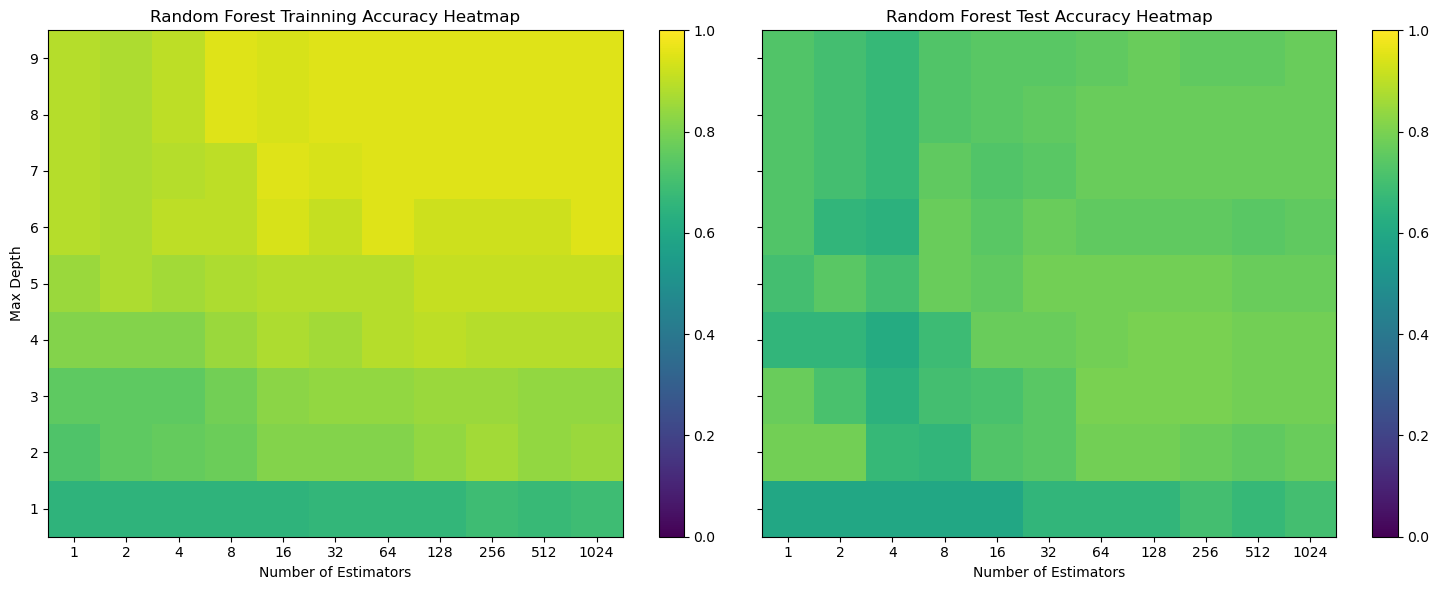

In [18]:
# Your plotting code here. Aim for 8-10 lines.
fig, axes = plt.subplots(1,2,figsize=(15, 6),sharey=True)
plt.sca(axes[0])
plt.imshow(accuracies_train, origin='lower', aspect='auto', vmin=0, vmax=1, cmap='viridis')
plt.colorbar()
plt.xticks(range(len(n_estimators)), n_estimators)
plt.yticks(range(len(max_depths)), max_depths)
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.title('Random Forest Trainning Accuracy Heatmap')

plt.sca(axes[1])
plt.imshow(accuracies_test,  origin='lower', aspect='auto', vmin=0, vmax=1, cmap='viridis')
plt.title('Random Forest Test Accuracy Heatmap')
plt.xticks(range(len(n_estimators)), n_estimators)
plt.yticks(range(len(max_depths)), max_depths)
plt.colorbar()
plt.xlabel('Number of Estimators')
plt.tight_layout()

For what combination(s) of (*max_depth*, *n_estimators*) does the random forest classifier have highest accuracy on the test data? Is the accuracy trend on the test data different than the trend on the training data?

**Answer:**
The highest accuracy on the test data is 80.0%; And the combinations can be (max_depth,n_estimators) = (3,64), (3, 128), (3, 256),
(4, 128), and (4, 256).
Training accuracy generally increases as
max_depth increases and then plateaus. However, test accuracy reaches
its maximum at moderate depths (3 or 4) and does not continue increasing.


In [19]:
max_accuracy = np.max(accuracies_test)
print(f"Max test accuracy: {max_accuracy*100:.1f}%")
indices = np.where(accuracies_test == max_accuracy)
for i, j in zip(*indices):
    print(
        f"max_depth={max_depths[i]}, "
        f"n_estimators={n_estimators[j]}"
    )

Max test accuracy: 80.0%
max_depth=3, n_estimators=64
max_depth=3, n_estimators=128
max_depth=3, n_estimators=256
max_depth=4, n_estimators=128
max_depth=4, n_estimators=256


## Livrables
##### 1. Créez un fichier ZIP contenant les fichiers de code source nécessaires (notebook - ipynb). Vous devez nommer votre fichier selon la convention suivante : A#_IDétudiant, où # est le numéro du devoir et IDétudiant est votre numéro d'identifiant étudiant.
##### 2. Les devoirs doivent être remis dans la section des devoirs (Léa) au plus tard le 01 Août 2026 à 23h55.